In [1]:
!nvidia-smi

Sun Apr 26 23:55:13 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import os
HOME = os.getcwd()
print(HOME)

/kaggle/working


In [3]:
!pip install roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.0/184.0 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 39.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 67.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 82.2 MB/s eta 0:00:00ta 0:00:01
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.25.1 requires google-cloud-big

In [4]:
from roboflow.core.dataset import Dataset

# Create a Dataset object by specifying its properties
# name: name of the dataset
# version: version number
# model_format: format (e.g., 'yolov8', 'coco', 'voc')
# location: local path to the downloaded dataset folder
dataset = Dataset(
    name="my-custom-dataset",
    version=1,
    model_format="yolov8",
    location="/kaggle/input/datasets/bitwander/uav-detection/master_dataset"
)

# Access dataset properties
print(dataset.name)
print(dataset.version)
print(dataset.location)

my-custom-dataset
1
/kaggle/input/datasets/bitwander/uav-detection/master_dataset


In [ ]:
# Setting up YOLOV8 to train on Custom Dataset
# Pip install method (recommended)

!pip install ultralytics==8.2.103 -q

from IPython import display
display.clear_output()

# prevent ultralytics from tracking your activity
!yolo settings sync=False

import ultralytics
ultralytics.checks()

In [ ]:
from ultralytics import YOLO

from IPython.display import display, Image

In [ ]:
# To monitor deep learning experiments install clearml
!pip install clearml

In [ ]:
%env CLEARML_WEB_HOST=https://app.clear.ml/
%env CLEARML_API_HOST=https://api.clear.ml
%env CLEARML_FILES_HOST=https://files.clear.ml
%env CLEARML_API_ACCESS_KEY=RZ5HK818UR6ATC5F649H7TFTJP84PC
%env CLEARML_API_SECRET_KEY=q3O5PrykLlRCIGKCqRTgyQI72BvZlmXkcgEjsGYO_o-li1jCuE5v7TdABUp0sny1tJ8

In [ ]:
!pip uninstall -y ray

In [10]:

!yolo task=detect mode=train model=yolov8n.pt data={dataset.location}/data.yaml epochs=100 imgsz=640 batch=64 plots=True workers=4 device=0,1

Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytics

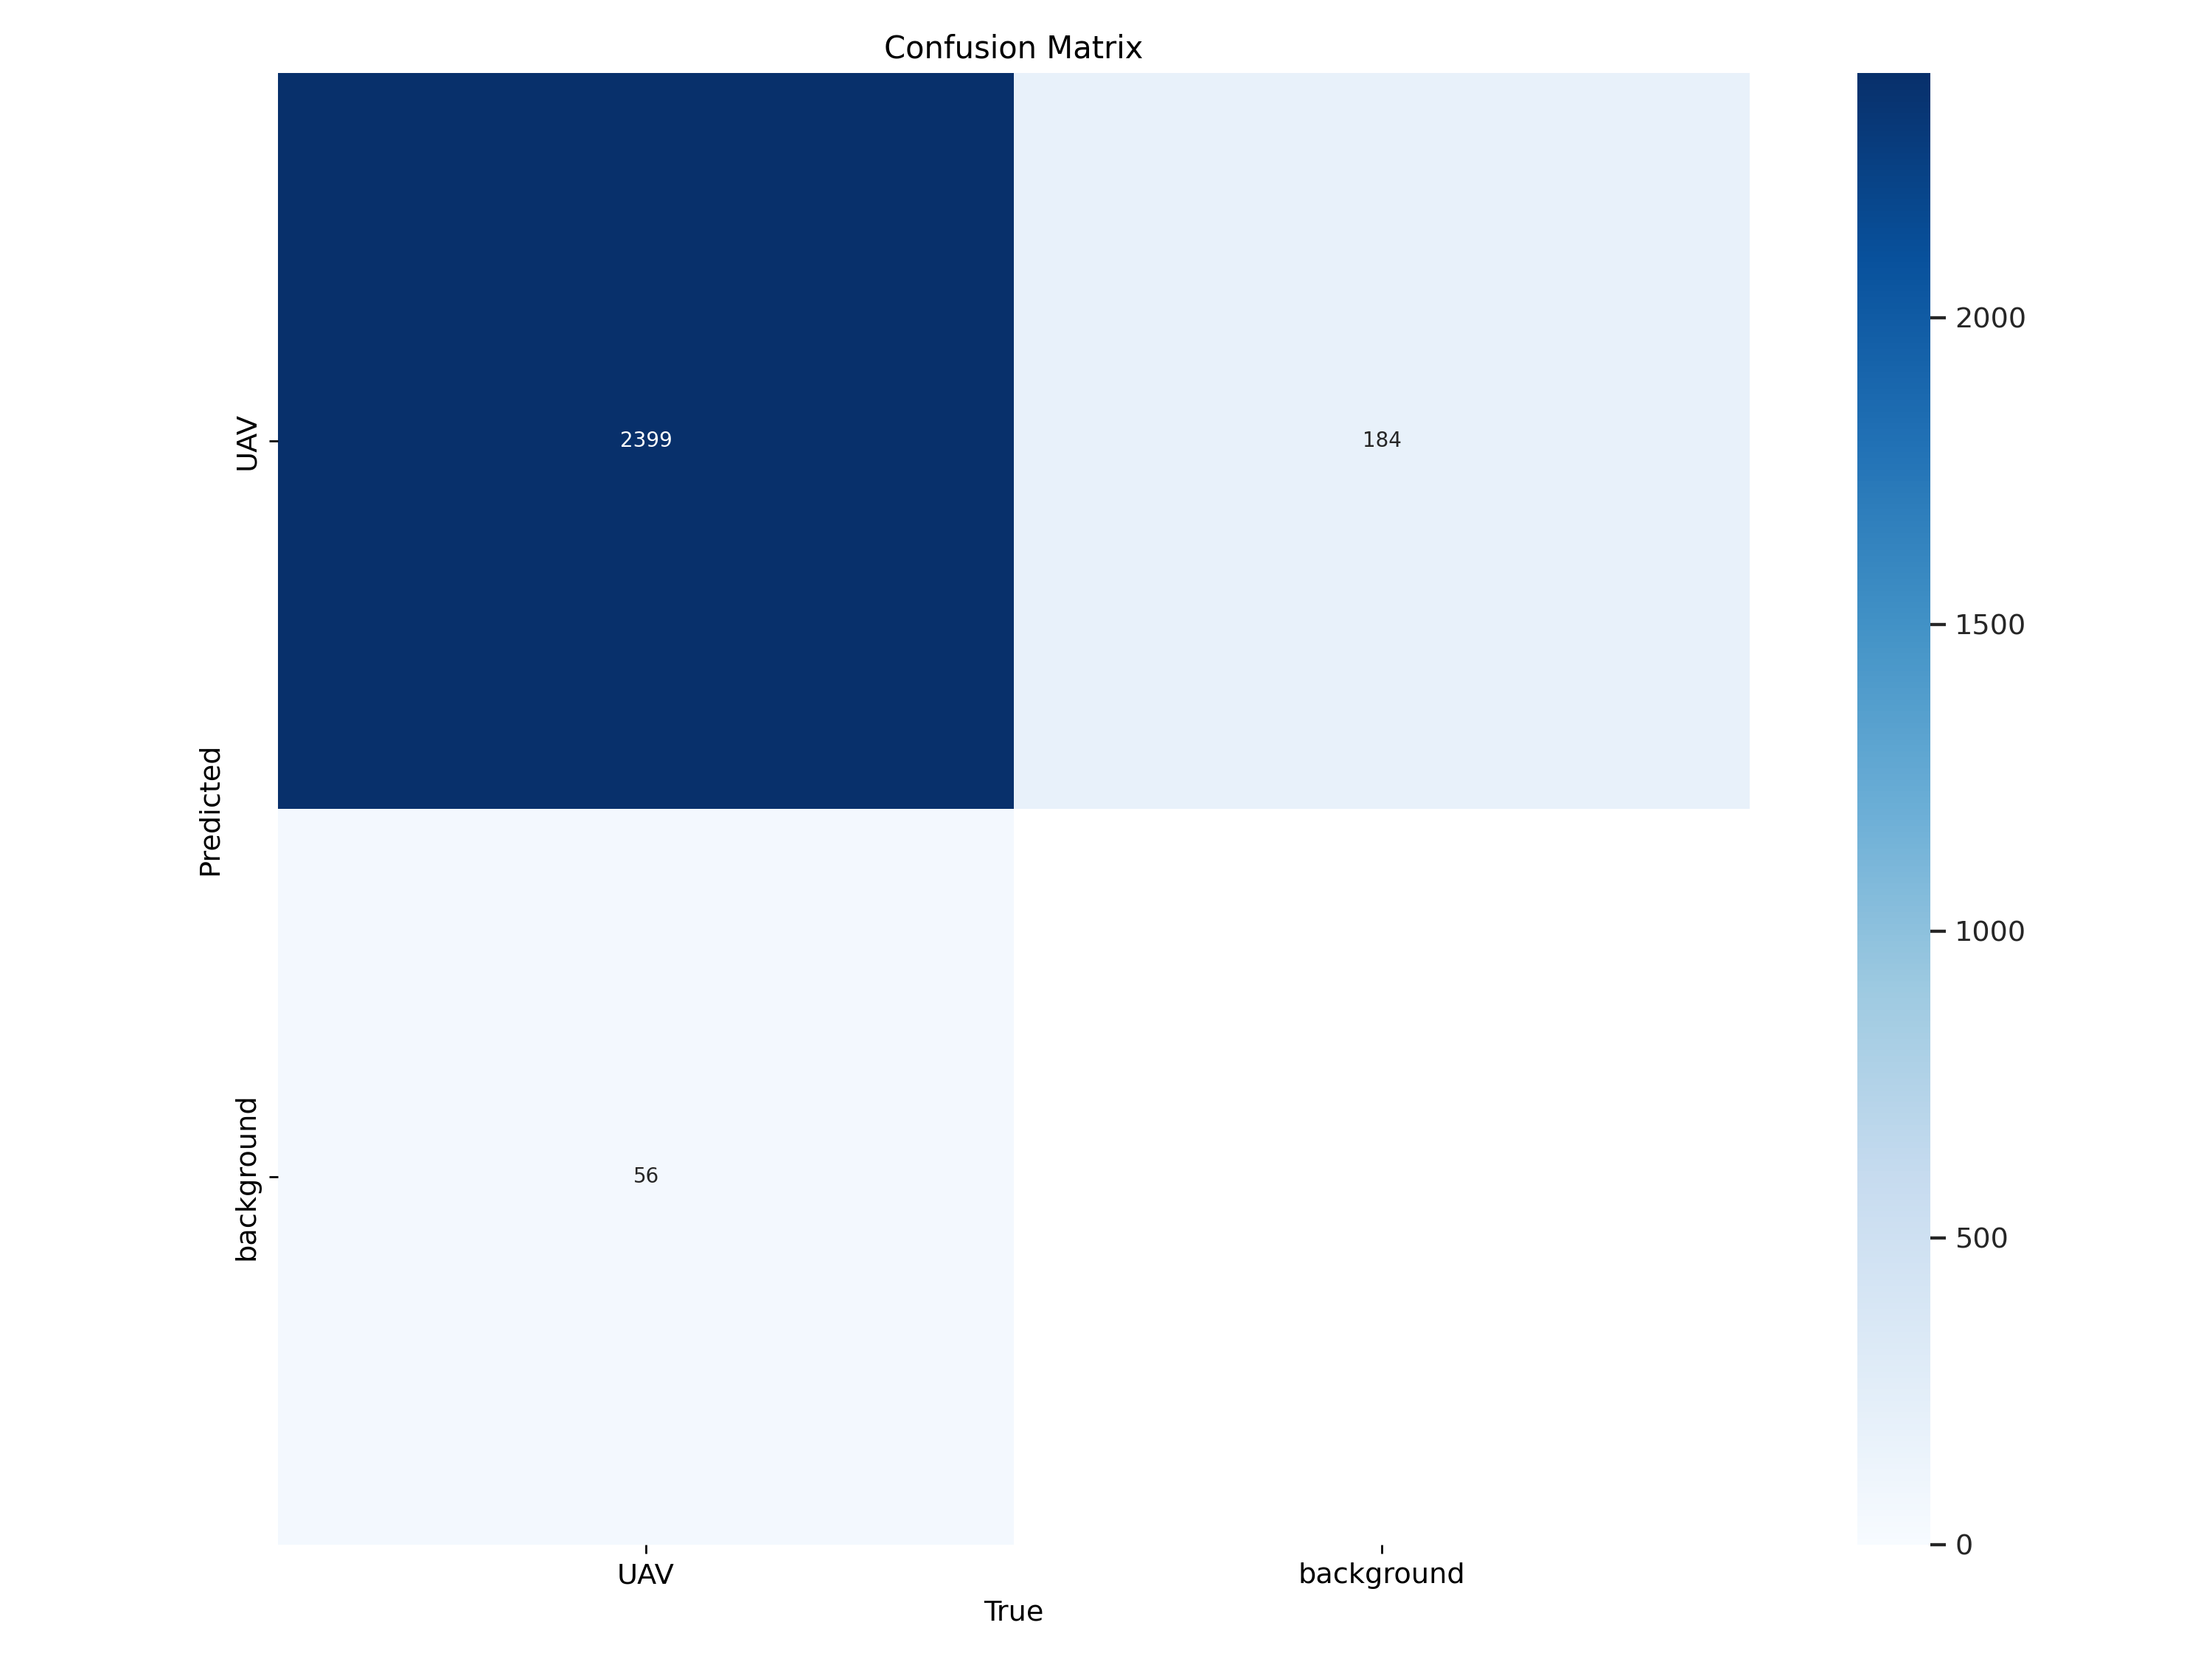

In [11]:
Image(filename=f'{HOME}/runs/detect/train/confusion_matrix.png', width=600)

In [12]:
%cd {HOME}
!yolo task=detect mode=predict model={HOME}/runs/detect/train/weights/best.pt conf=0.25 source={dataset.location}/test/images save=True

/kaggle/working
Ultralytics YOLOv8.2.103 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 168 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs

image 1/2390 /kaggle/input/datasets/bitwander/uav-detection/master_dataset/test/images/ds0_-_-150-_jpg.rf.6cc884a90ffd40ec38883e80a7fd8a9d.jpg: 640x640 2 UAVs, 7.2ms
image 2/2390 /kaggle/input/datasets/bitwander/uav-detection/master_dataset/test/images/ds0_-_-186-_jpg.rf.ca9133c0c0b21e243a0cb5be4cd2528f.jpg: 640x640 1 UAV, 7.2ms
image 3/2390 /kaggle/input/datasets/bitwander/uav-detection/master_dataset/test/images/ds0_-_-266-_jpg.rf.0e183d5ae032215d7b29de564e7c3b4a.jpg: 640x640 1 UAV, 7.2ms
image 4/2390 /kaggle/input/datasets/bitwander/uav-detection/master_dataset/test/images/ds0_-_-79-_jpg.rf.118d4864854581216afbbafc782d5c15.jpg: 640x640 1 UAV, 7.2ms
image 5/2390 /kaggle/input/datasets/bitwander/uav-detection/master_dataset/test/images/ds0_-_-83-_jpg.rf.41f4da17989be90ac5e4689d2d3b8a4b.jpg: 640x640 2 

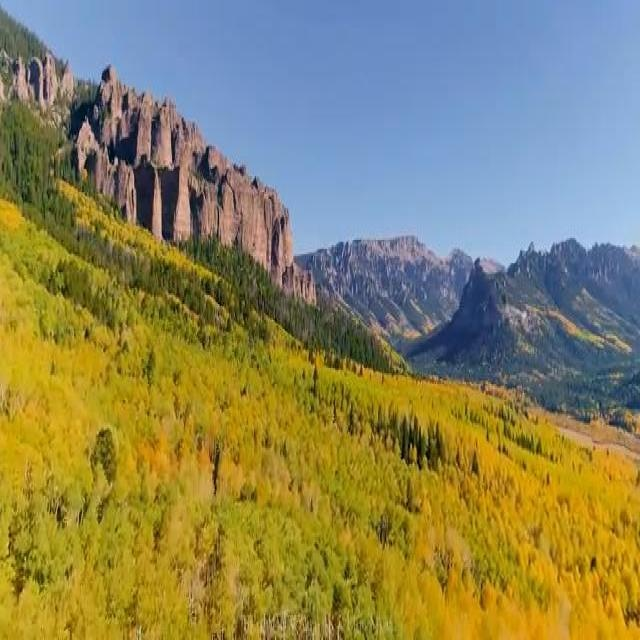

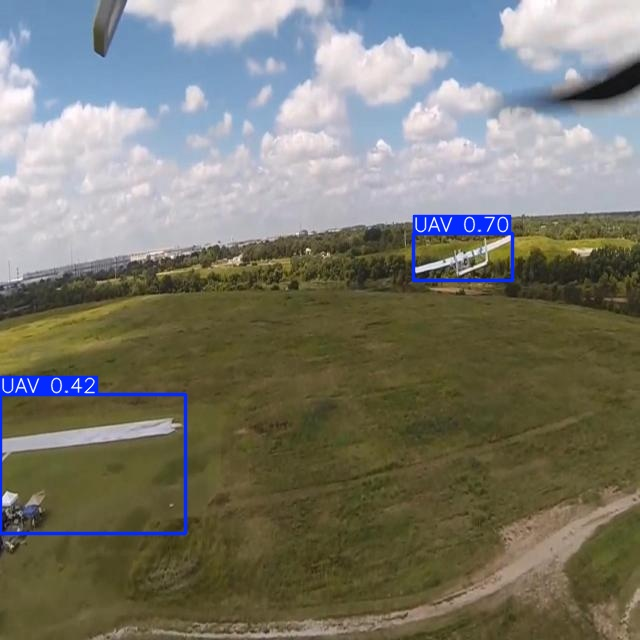

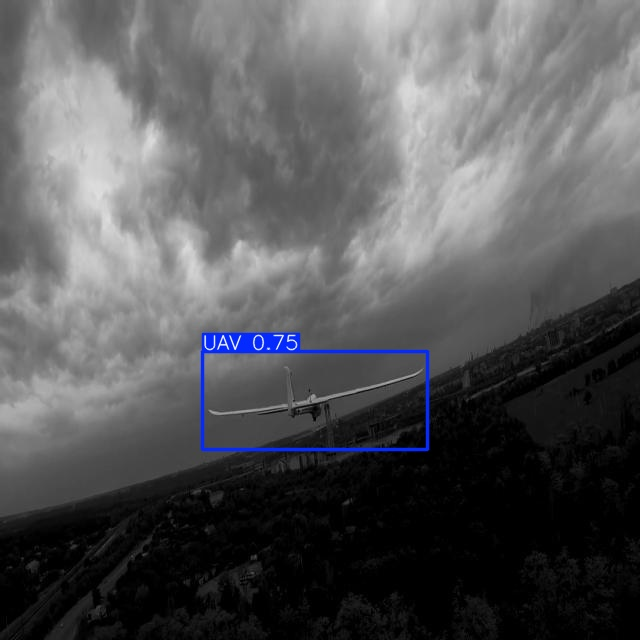

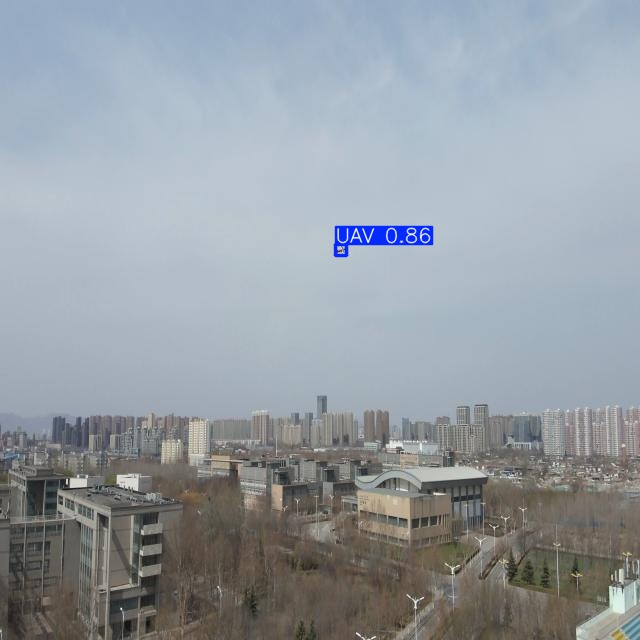

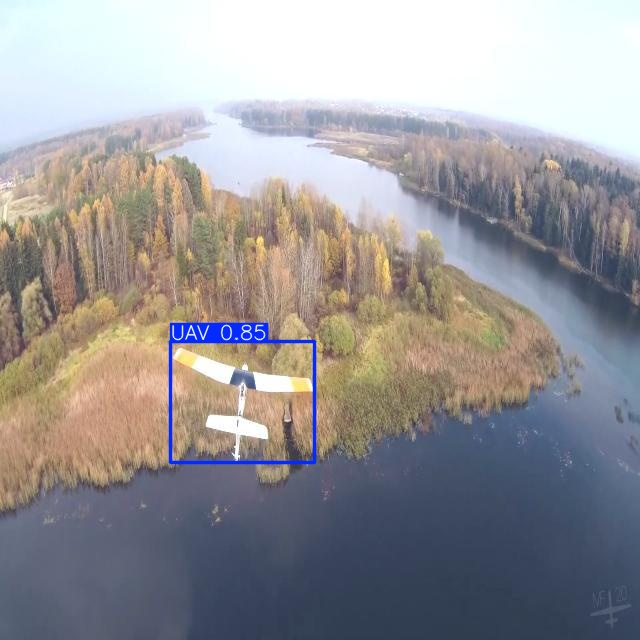

In [13]:
import glob
from IPython.display import Image, display

# Define the base path where the folders are located
base_path = '/kaggle/working/runs/detect'

# List all directories that start with 'predict' in the base path
subfolders = [os.path.join(base_path, d) for d in os.listdir(base_path)
              if os.path.isdir(os.path.join(base_path, d)) and d.startswith('predict')]

# Find the latest folder by modification time
latest_folder = max(subfolders, key=os.path.getmtime)

image_paths = glob.glob(f'{latest_folder}/*.jpg')[:5]

# Display each image
for image_path in image_paths:
    display(Image(filename=image_path, width=600))
    print("\n")